# LV7 - nenadzirano učenje

- dosada smo radili nadzirano učenje - tip učenja kojem je cilj iz ulaznih podataka X predvidjeti izlaznu varijablu y
- međutim, to nije jedini tip učenja - postoji i nenadzirano učenje
- njemu je cilj iz danih podataka izvući neke zaključke bez postojanja izlazne varijable y
- u ovoj vježbi obradili smo problem grupiranja (clustering) uz pomoć nenadziranog učenja

### K-Means algoritam
- jedan od popularnih algoritama grupiranja je algoritam K srednjih vrijednosti
- on će svaku grupu predstaviti centrom - m-dimenzionalnim vektorom
- svaki podatkovni primjer pripada samo jednoj grupi
- cilj k-means algoritma je pronaći optimalne vrijednosti centara i to čini minimizacijom sume kvadrata udaljenosti svakog primjerka od njemu najbližeg centra
- ta suma naziva se kriterijska funkcija J
- taj postupak provodi iterativno - dodaje podatkovni primjerak njemu najbližem centru, a zatim određuje novu vrijednost centra
- pri prvoj iteraciji postoje dva načina odabira centara:
    - nasumično
    - k-means++ - nasumično odabire prvi centar, a svaki sljedeći smješta što dalje od postojećih centara
- moguće je dati željeni broj centara (k) modelu kao hiperparametar
- ako nam k nije poznat, moguće je odrediti optimalnu vrijednost koristeći lakat metodu (elbow method)
    - promatramo ovisnost iznosa kriterijske funkcije J i broja klastera K
    - što je veći broj klastera, to će više J padati - ali nakon nekog (iz grafa jasno vidljivog) broja K, vrijednost J će prestati naglo padati
    - taj "lakat" na grafu nam je optimalna vrijednost K

In [1]:
from sklearn.cluster import KMeans

Primjer:

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv('Social_Network_Ads.csv')

data = data.drop(columns='User ID') # nije nam bitan za učenje
data = pd.get_dummies(data, columns=['Gender'])

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
data = scaler.fit_transform(data)

model = KMeans().fit(data)
labels = model.predict(data)

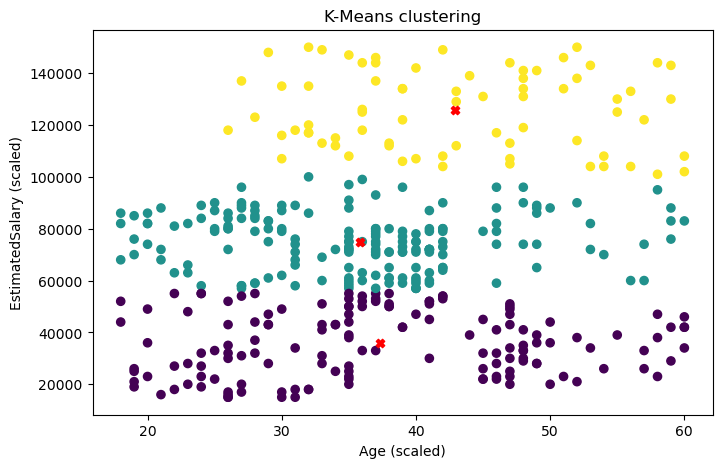

In [11]:
data = pd.read_csv('Social_Network_Ads.csv')
data = data.drop(columns=['User ID'])
data = pd.get_dummies(data, columns=['Gender'], drop_first=True)

X = data[['Age', 'EstimatedSalary']]

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels = kmeans.fit_predict(X)

plt.figure(figsize=(8, 5))
plt.scatter(X['Age'], X['EstimatedSalary'], c=labels, cmap='viridis', s=35)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], c='red', marker='X')
plt.xlabel('Age (scaled)')
plt.ylabel('EstimatedSalary (scaled)')
plt.title('K-Means clustering')
plt.show()